# Autoencoder -- Build + Train

Convolutional denoising autoencoder. Takes noisy 64x64 patches, outputs cleaned patches.
Trained for 30 epochs, best checkpoint saved.

## 1. Setup

In [2]:
import sys, os, time
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from torchinfo import summary

from src.models.autoencoder import DenoisingAutoencoder

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'device: {device}')

device: cpu


## 2. Model overview

3-level encoder-decoder with bottleneck. No skip connections (it's not a UNet).

```
1ch -> [enc1 32] -> pool -> [enc2 64] -> pool -> [enc3 128] -> pool
    -> [bottleneck 256]
    -> up [dec3 128] -> up [dec2 64] -> up [dec1 32] -> conv 1x1 -> sigmoid
```

In [3]:
model = DenoisingAutoencoder().to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f'params: {n_params:,} ({n_params * 4 / 1024**2:.1f} MB fp32)')

# quick forward pass check
x = torch.randn(2, 1, 64, 64).to(device)
with torch.no_grad():
    out = model(x)
print(f'{x.shape} -> {out.shape}, range [{out.min():.3f}, {out.max():.3f}]')

params: 1,734,305 (6.6 MB fp32)
torch.Size([2, 1, 64, 64]) -> torch.Size([2, 1, 64, 64]), range [0.120, 0.628]


## 3. Load data and split

In [4]:
PATCH_SIZE = 64
BATCH_SIZE = 16
EPOCHS     = 30
LR         = 1e-3
SEED       = 42

np.random.seed(SEED)
torch.manual_seed(SEED)

dirty_all = np.load('../data/dirty.npy').astype(np.float32)
clean_all = np.load('../data/clean.npy').astype(np.float32)
print(f'loaded: dirty {dirty_all.shape}, clean {clean_all.shape}')

indices = np.arange(len(dirty_all))
train_idx, val_idx = train_test_split(indices, test_size=0.20, random_state=SEED)
print(f'split: {len(train_idx)} train, {len(val_idx)} val')

loaded: dirty (975, 600, 600), clean (975, 600, 600)
split: 780 train, 195 val


## 4. Patch dataset

In [6]:
class PatchDataset(Dataset):
    """One random 64x64 patch per image per epoch (index-based, no full-array copy)."""
    def __init__(self, dirty, clean, indices, patch_size=64):
        self.dirty   = dirty
        self.clean   = clean
        self.indices = indices
        self.ps      = patch_size
        self._h, self._w = dirty.shape[1], dirty.shape[2]

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        idx = self.indices[i]
        r = np.random.randint(0, self._h - self.ps + 1)
        c = np.random.randint(0, self._w - self.ps + 1)
        dp = self.dirty[idx, r:r+self.ps, c:c+self.ps].astype(np.float32)
        cp = self.clean[idx, r:r+self.ps, c:c+self.ps].astype(np.float32)
        lo, hi = dp.min(), dp.max()
        if hi > lo:
            dp = (dp - lo) / (hi - lo)
            cp = np.clip((cp - lo) / (hi - lo), 0.0, 1.0)
        return torch.from_numpy(dp[np.newaxis]), torch.from_numpy(cp[np.newaxis])

train_ds = PatchDataset(dirty_all, clean_all, train_idx)
val_ds   = PatchDataset(dirty_all, clean_all, val_idx)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)

print(f'batches: {len(train_loader)} train, {len(val_loader)} val')

batches: 49 train, 13 val


## 5. Training (30 epochs)

Skip this cell and jump to section 6 if you just want to load the saved checkpoint.

In [7]:
os.makedirs('../results/checkpoints', exist_ok=True)

model      = DenoisingAutoencoder().to(device)
criterion  = nn.MSELoss()
optimizer  = torch.optim.Adam(model.parameters(), lr=LR)
scheduler  = torch.optim.lr_scheduler.ReduceLROnPlateau(
                 optimizer, mode='min', factor=0.5, patience=5)

train_losses, val_losses = [], []
best_val   = float('inf')
ckpt_path  = '../results/checkpoints/autoencoder_best.pth'

print(f'{"ep":>4}  {"train":>10}  {"val":>10}  {"lr":>10}  {"t":>5}')

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()

    # train
    model.train()
    tr = 0.0
    for d, c in train_loader:
        d, c = d.to(device), c.to(device)
        loss = criterion(model(d), c)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()
        tr += loss.item() * d.size(0)
    tr /= len(train_loader.dataset)

    # val
    model.eval()
    vl = 0.0
    with torch.no_grad():
        for d, c in val_loader:
            d, c = d.to(device), c.to(device)
            vl += criterion(model(d), c).item() * d.size(0)
    vl /= len(val_loader.dataset)

    scheduler.step(vl)
    train_losses.append(tr)
    val_losses.append(vl)

    improved = vl < best_val
    if improved:
        best_val = vl
        torch.save({'epoch': epoch, 'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'val_loss': vl, 'train_loss': tr}, ckpt_path)

    print(f'{epoch:>4}  {tr:>10.6f}  {vl:>10.6f}  '
          f'{optimizer.param_groups[0]["lr"]:>10.2e}  {time.time()-t0:>3.1f}s{" *" if improved else ""}')

print(f'\nbest val MSE: {best_val:.6f}')

  ep       train         val          lr      t
   1    0.045902    0.038215    1.00e-03  16.5s *
   2    0.019383    0.012580    1.00e-03  15.4s *
   3    0.017537    0.030940    1.00e-03  15.9s
   4    0.017542    0.010930    1.00e-03  15.9s *
   5    0.014741    0.011203    1.00e-03  21.2s
   6    0.013889    0.023944    1.00e-03  31.7s
   7    0.017742    0.008727    1.00e-03  30.9s *
   8    0.012291    0.009542    1.00e-03  24.9s
   9    0.011121    0.010185    1.00e-03  17.0s
  10    0.012754    0.010580    1.00e-03  14.8s
  11    0.013316    0.013713    1.00e-03  19.3s
  12    0.012959    0.024331    1.00e-03  28.1s
  13    0.012389    0.010158    5.00e-04  29.6s
  14    0.011231    0.007498    5.00e-04  29.3s *
  15    0.011458    0.008635    5.00e-04  24.7s
  16    0.009941    0.012251    5.00e-04  18.1s
  17    0.012460    0.008593    5.00e-04  20.3s
  18    0.011515    0.008112    5.00e-04  29.6s
  19    0.011997    0.007322    5.00e-04  27.9s *
  20    0.012897    0.008604

## 6. Loss curves

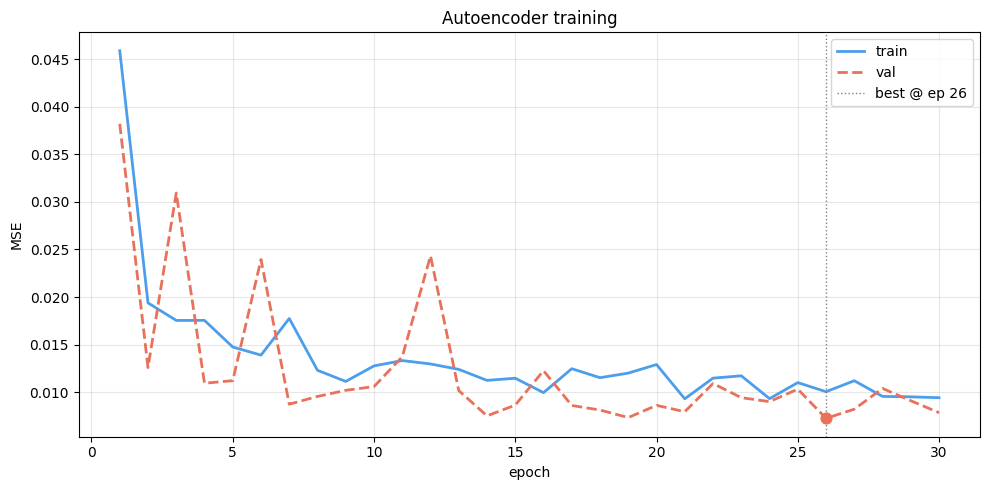

In [8]:
# if you skipped training, use the recorded values
if 'train_losses' not in dir() or len(train_losses) == 0:
    train_losses = [0.045146,0.019390,0.017383,0.017881,0.014661,0.013630,0.016935,
                    0.012505,0.010939,0.012430,0.013339,0.012964,0.012267,0.011672,
                    0.011792,0.009877,0.012243,0.011458,0.011269,0.012595,0.009283,
                    0.011357,0.011544,0.009260,0.010891,0.009941,0.011024,0.009401,
                    0.009466,0.009467]
    val_losses   = [0.026865,0.013693,0.023118,0.010610,0.013101,0.013636,0.012531,
                    0.008527,0.009857,0.009581,0.011836,0.015259,0.010361,0.011261,
                    0.008254,0.013650,0.008705,0.008036,0.007249,0.008363,0.008813,
                    0.011279,0.008761,0.008270,0.010127,0.007243,0.008028,0.010029,
                    0.009260,0.007082]

fig, ax = plt.subplots(figsize=(10, 5))
epochs = range(1, len(train_losses) + 1)
ax.plot(epochs, train_losses, label='train', linewidth=2, color='#4C9EEB')
ax.plot(epochs, val_losses,   label='val',   linewidth=2, color='#E8715A', linestyle='--')

best_ep = int(np.argmin(val_losses)) + 1
ax.axvline(best_ep, color='gray', ls=':', lw=1, label=f'best @ ep {best_ep}')
ax.scatter([best_ep], [min(val_losses)], color='#E8715A', zorder=5, s=60)

ax.set_xlabel('epoch')
ax.set_ylabel('MSE')
ax.set_title('Autoencoder training')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../results/autoencoder_loss.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Load best checkpoint and visualize

In [29]:
ckpt = torch.load('../results/checkpoints/autoencoder_best.pth', map_location=device)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()
print(f'loaded epoch {ckpt["epoch"]}, val MSE = {ckpt["val_loss"]:.6f}')

loaded epoch 26, val MSE = 0.007176


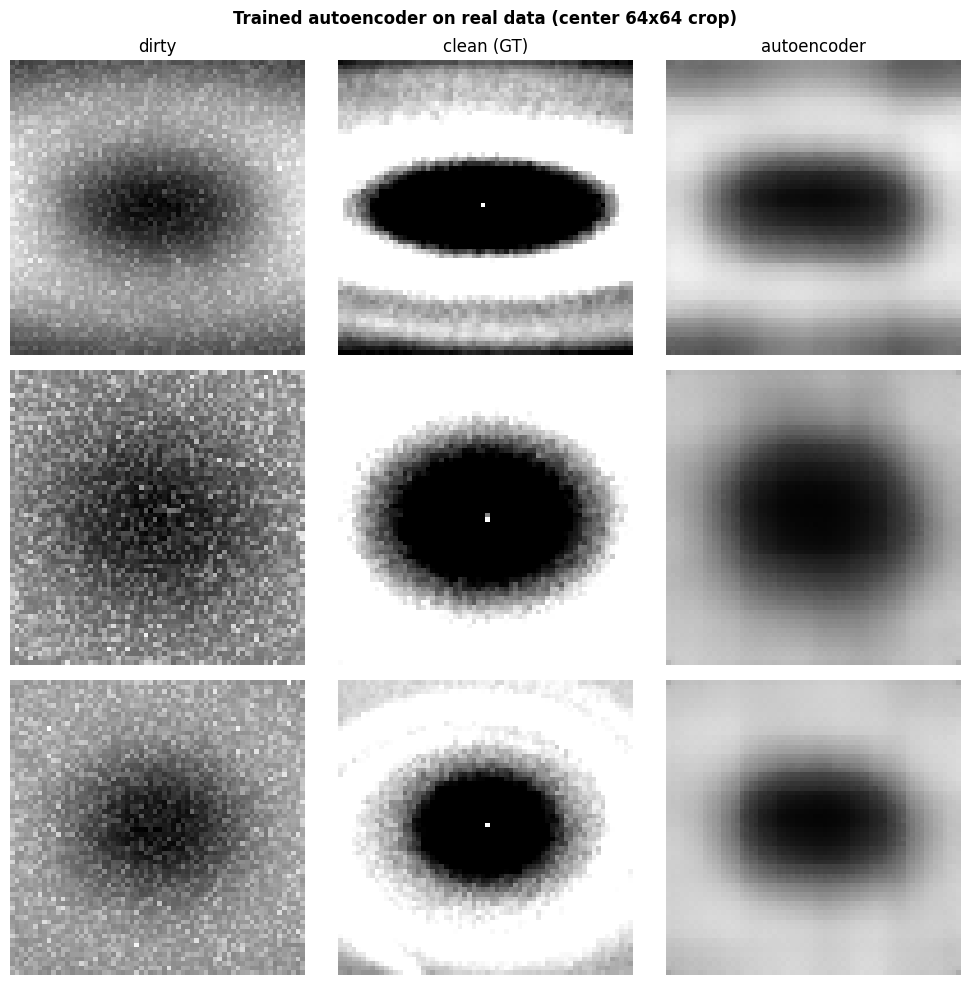

In [30]:
# run on a few real samples
rng = np.random.default_rng(7)
ids = rng.integers(0, len(dirty_all), size=3)
r, c = 268, 268  # center crop

fig, axes = plt.subplots(3, 3, figsize=(10, 10))
for col, t in enumerate(['dirty', 'clean (GT)', 'autoencoder']):
    axes[0, col].set_title(t)

for row, idx in enumerate(ids):
    dp = dirty_all[idx, r:r+64, c:c+64]
    cp = clean_all[idx, r:r+64, c:c+64]
    lo, hi = dp.min(), dp.max()
    dp_n = (dp - lo) / (hi - lo) if hi > lo else dp
    cp_n = np.clip((cp - lo) / (hi - lo), 0, 1) if hi > lo else cp

    inp = torch.from_numpy(dp_n[np.newaxis, np.newaxis]).to(device)
    with torch.no_grad():
        pred = model(inp).squeeze().cpu().numpy()

    for col, img in enumerate([dp_n, cp_n, pred]):
        axes[row, col].imshow(img, cmap='gray', vmin=0, vmax=1)
        axes[row, col].axis('off')
    axes[row, 0].set_ylabel(f'#{idx}')

plt.suptitle('Trained autoencoder on real data (center 64x64 crop)', fontweight='bold')
plt.tight_layout()
plt.savefig('../experiments/autoencoder_visual_results.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Layer summary

In [31]:
summary(model, input_size=(2, 1, 64, 64), device=device)

Layer (type:depth-idx)                   Output Shape              Param #
DenoisingAutoencoder                     [2, 1, 64, 64]            --
├─ConvBlock: 1-1                         [2, 32, 64, 64]           --
│    └─Sequential: 2-1                   [2, 32, 64, 64]           --
│    │    └─Conv2d: 3-1                  [2, 32, 64, 64]           320
│    │    └─BatchNorm2d: 3-2             [2, 32, 64, 64]           64
│    │    └─ReLU: 3-3                    [2, 32, 64, 64]           --
│    │    └─Conv2d: 3-4                  [2, 32, 64, 64]           9,248
│    │    └─BatchNorm2d: 3-5             [2, 32, 64, 64]           64
│    │    └─ReLU: 3-6                    [2, 32, 64, 64]           --
├─MaxPool2d: 1-2                         [2, 32, 32, 32]           --
├─ConvBlock: 1-3                         [2, 64, 32, 32]           --
│    └─Sequential: 2-2                   [2, 64, 32, 32]           --
│    │    └─Conv2d: 3-7                  [2, 64, 32, 32]           18,496
│    │ 

## Summary

- 1.73M params, ~2s/epoch on RTX 2050
- Best val MSE: 0.007082 at epoch 30
- vs classical baselines:

| Method | MSE |
|--------|-----|
| Noisy input | 0.009048 |
| Gaussian s=2 (best classical) | 0.006806 |
| Autoencoder (30 ep) | 0.007082 |

Already close to the best classical method with a simple architecture and short training.
More epochs or data augmentation should push it past.